# 03 - ML Model Training
Train Random Forest baseline model

In [17]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded')

Libraries loaded


In [18]:
# Load preprocessed data from feature engineering
df = pd.read_csv('data/EURUSD_H1_ML.csv', index_col=0)
print(f'Data loaded: {df.shape}')
df.head(3)

Data loaded: (3560, 33)


,sma_10,sma_20,sma_50,ema_12,ema_26,pct_from_sma20,pct_from_sma50,rsi,macd,macd_signal,...,body_ratio,range,range_pct,tick_volume,volume_ma,volume_ratio,close_lag1,close_lag2,rsi_lag1,Target
time,,,,,,,,,,,,,,,,,,,,,
2025-08-12 17:00:00,1.162272,1.161958,1.163344,1.162797,1.162554,0.326303,0.206783,74.704895,0.000243,-0.000324,...,0.272727,0.00209,0.179284,2402,2870.65,0.836744,1.16517,1.16416,72.487195,1
2025-08-12 18:00:00,1.162856,1.162295,1.163391,1.163468,1.162896,0.418612,0.323932,79.369515,0.000573,-0.000144,...,0.347188,0.00409,0.350423,2234,2887.90,0.773572,1.16575,1.16517,74.704895,1
2025-08-12 19:00:00,1.163559,1.162607,1.163438,1.164149,1.163265,0.454410,0.382642,81.416688,0.000883,0.000061,...,0.356436,0.00202,0.172961,1937,2915.20,0.664448,1.16716,1.16575,79.369515,1


## 1. Separate X & y + Train/Test Split
**shuffle=False** para hindi masira ang time order

In [19]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in df.columns if c != 'Target']

X = df[feature_cols]
y = df['Target']

# Split — 80% train, 20% test, NO shuffle (time series!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f'X: {X.shape}')
print(f'y: BUY={y.sum()}, SELL={(y==0).sum()}')
print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

X: (3560, 32)
y: BUY=1653, SELL=1907
Train: 2848 samples
Test:  712 samples


## 2. Train Random Forest (Baseline)

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print('Model trained!')

Model trained!


## 3. Evaluate

In [21]:
y_pred = model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.2%}')
print()
print(classification_report(y_test, y_pred, target_names=['SELL', 'BUY']))

Accuracy: 36.10%

              precision    recall  f1-score   support

        SELL       0.36      0.34      0.35       357
         BUY       0.37      0.38      0.37       355

    accuracy                           0.36       712
   macro avg       0.36      0.36      0.36       712
weighted avg       0.36      0.36      0.36       712



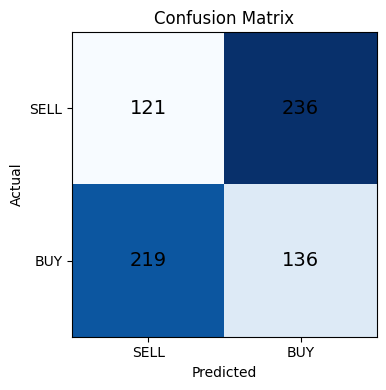

In [22]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['SELL', 'BUY'])
ax.set_yticklabels(['SELL', 'BUY'])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14)

ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 4. Feature Importance (Ano pinaka-importante?)

In [23]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print('Top 10 most important features:')
importance.head(10)

Top 10 most important features:


,feature,importance
2,sma_50,0.066773
27,volume_ma,0.061820
6,pct_from_sma50,0.060019
11,bb_upper,0.054309
4,ema_26,0.049920
1,sma_20,0.048591
9,macd_signal,0.048516
12,bb_lower,0.047757
13,bb_width,0.044992
8,macd,0.043428


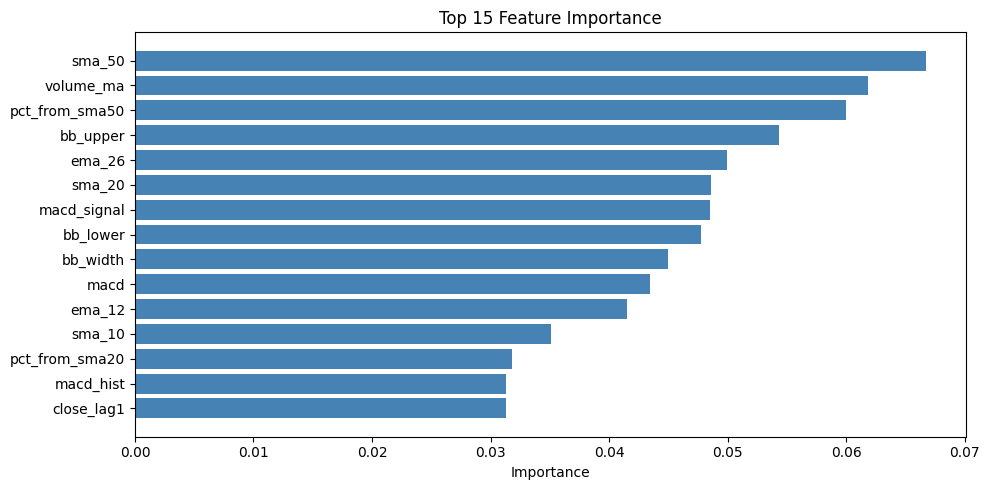

In [24]:
# Plot feature importance
top15 = importance.head(15)
plt.figure(figsize=(10, 5))
plt.barh(range(len(top15)), top15['importance'], color='steelblue')
plt.yticks(range(len(top15)), top15['feature'])
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()